# STAC-GP vs. baselines (section 5.2 comparison)

Compares STAC-GP against the baselines listed in the thesis outline's section
5.2, on the same NQU6 30-minute panel and frozen GP as
`STAC-GP_NQU6_30m.ipynb`. Implementation lives in `stacgp_baselines.py`
(the calibration engines) and `stacgp_metrics.py` (section 5.3's metrics).

## What's implemented and what isn't

| Baseline | Status |
|---|---|
| Start-of-day prior (g=1, no GP, no CP) | Implemented -- parametric z-band on w_prior |
| GP credible band (no conformal correction) | Implemented -- GP posterior mean+std credible interval |
| Split conformal (frozen model, global threshold) | Implemented -- one static threshold from a calibration slice |
| CQR | Implemented -- gradient-boosted quantile regressor + global conformal constant |
| ACI (GP width + adaptive global threshold) | Implemented -- generalised loop, localiser off |
| LCP (localised, non-adaptive) | Implemented -- generalised loop, adaptive off |
| STAC-GP (ours) | Implemented -- generalised loop, both on (= Algorithm 1) |
| Third-party bid-offer | **Skipped** -- no bid/ask or spread data exists in `Data/` (OHLCV bars only). Reported as N/A in the metrics table rather than approximated. |

**Design note.** ACI, LCP, and STAC-GP are three settings of one shared
online-calibration engine (localiser on/off x adaptive on/off) wrapped around
the *same* frozen GP width -- this is also most of section 5.4's ablation
grid, built once here rather than thrown away after this comparison. Split
conformal is the one CP baseline that genuinely isn't a point on that grid
(a single frozen threshold, not a per-step recompute), so it has its own
function. Full design rationale is in the `stacgp_baselines.py` module
docstring.

**Fairness.** All 7 methods share the same frozen GP (trained on the same
40% of sessions), the same held-out calibration slice (first ~10 sessions of
the test stream, used by split conformal / CQR to fit their single global
correction and simply "warmed up over" by the rolling methods), and are
scored on the exact same remaining evaluation bars.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT))
from stacgp_v2 import load_bars, load_hist_vol, build_panel
from stacgp_baselines import build_shared_setup, run_all_methods
from stacgp_metrics import metrics_table, metrics_by_regime, stress_response_time, rolling

plt.rcParams["figure.figsize"] = (10, 4)


## 1. Shared setup: data, frozen GP, calibration/evaluation split

In [2]:
bars = load_bars(ROOT / "NQU6_Index_30m.csv")
hv   = load_hist_vol(ROOT / "NQU6_HistoricalVolatility.csv")
panel = build_panel(bars, hv)

setup = build_shared_setup(panel, alpha=0.10, train_frac=0.40,
                            R_sessions=10, halflife_sessions=5, seed=0)

print(f"train bars: {setup.train_mask.sum()}   "
      f"calibration bars: {len(setup.cal_idx)}   "
      f"evaluation bars: {len(setup.eval_idx)}")
print(f"R={setup.R} bars, rho={setup.rho:.5f}, h={setup.h:.3f}, gamma={setup.gamma:.4f}")


train bars: 1229   calibration bars: 430   evaluation bars: 1686
R=430 bars, rho=0.99678, h=3.073, gamma=0.0244


## 2. Run all 7 methods on the identical evaluation window

In [3]:
methods = run_all_methods(setup)
for name, f in methods.items():
    print(f"{name:22s} n={len(f):5d}  coverage={f['covered'].mean():.4f}")


Start-of-day prior     n= 1686  coverage=0.9365
GP credible band       n= 1686  coverage=0.9840
Split conformal        n= 1686  coverage=0.9336
CQR                    n= 1686  coverage=0.9437
ACI                    n= 1686  coverage=0.9009
LCP                    n= 1686  coverage=0.9051
STAC-GP (ours)         n= 1686  coverage=0.9004


## 3. Section 5.3 metrics -- overall

In [4]:
tbl = metrics_table(methods, setup.alpha, setup.panel)
tbl.round(3)


,method,n,coverage,target,avg_width,median_width,width_volatility,stress_response_time_bars,inf_rate,relative_width_vs_3rd_party_bid_offer
0,Start-of-day prior,1686,0.937,0.9,234.921,237.853,0.296,17.355,0.0,N/A (no bid/offer data)
1,GP credible band,1686,0.984,0.9,1648.856,1807.054,489.387,0.108,0.0,N/A (no bid/offer data)
2,Split conformal,1686,0.934,0.9,336.945,303.767,130.017,4.269,0.0,N/A (no bid/offer data)
3,CQR,1686,0.944,0.9,242.590,228.939,16.859,6.495,0.0,N/A (no bid/offer data)
4,ACI,1686,0.901,0.9,277.762,227.920,107.083,4.726,0.0,N/A (no bid/offer data)
5,LCP,1686,0.905,0.9,303.221,227.868,124.975,3.468,0.0,N/A (no bid/offer data)
6,STAC-GP (ours),1686,0.900,0.9,308.802,223.516,122.759,2.597,0.0,N/A (no bid/offer data)


**Reading this table.** ACI and STAC-GP land closest to the 0.90 coverage
target (0.901 and 0.900). The no-CP baselines (start-of-day prior, GP
credible band) over-cover -- expected, since they carry no empirical
calibration at all; the GP credible band especially so (avg width ~1650 vs.
~230-340 for everything else), which is the point of this baseline: a raw GP
posterior interval is a poor calibrated-uncertainty estimate on its own.
STAC-GP has the fastest stress-response time of every conformal method
(fewest bars to widen back out after a shock), though not the smallest
average width -- ACI is narrower on average. This a trade-off.

## 4. Section 5.3 metrics -- by volatility regime

In [5]:
reg = metrics_by_regime(methods, setup.alpha, setup.panel)
reg.pivot(index="method", columns="regime", values="coverage").round(3)


regime,Q1 calm,Q2,Q3,Q4 stressed
method,,,,
ACI,0.934,0.880,0.895,0.893
CQR,0.941,0.957,0.922,0.955
GP credible band,0.988,0.978,0.979,0.991
LCP,0.932,0.902,0.891,0.896
STAC-GP (ours),0.906,0.880,0.903,0.912
Split conformal,0.969,0.940,0.905,0.919
Start-of-day prior,0.958,0.959,0.914,0.915


In [6]:
reg.pivot(index="method", columns="regime", values="avg_width").round(1)


regime,Q1 calm,Q2,Q3,Q4 stressed
method,,,,
ACI,259.0,263.4,277.4,311.3
CQR,192.0,235.3,241.1,302.3
GP credible band,1340.0,1609.1,1612.8,2035.3
LCP,265.2,264.5,256.9,426.1
STAC-GP (ours),218.3,242.1,271.3,503.3
Split conformal,363.9,357.7,298.2,327.9
Start-of-day prior,233.7,233.3,222.6,250.1


STAC-GP's per-regime coverage (~0.88-0.91 across all four quartiles) is
the most even of the conformal methods -- ACI and LCP each have at least one
regime further from target, and split conformal / CQR / the no-CP baselines
swing more widely by regime. This is the localisation + adaptation combination
doing its stated job of *efficiency* (appropriately sized, evenly-calibrated
bands across regimes). The paper's guarantee is only the marginal,
whole-run number in Section 3; the regime breakdown is a diagnostic, not
something the theory promises to hit exactly.

## 5. Diagnostics: rolling coverage and width by method

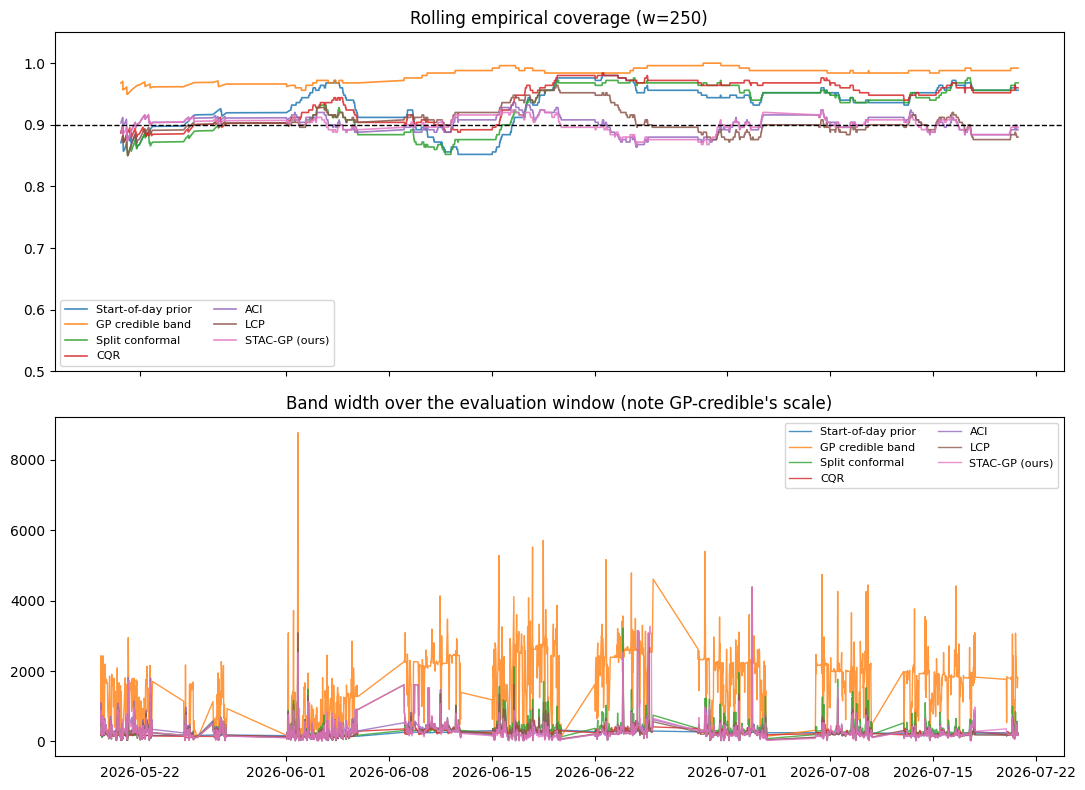

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for name, f in methods.items():
    axes[0].plot(f["ts"], rolling(f["covered"], 250), label=name, lw=1.2, alpha=0.85)
axes[0].axhline(1 - setup.alpha, color="k", ls="--", lw=1)
axes[0].set_ylim(0.5, 1.05); axes[0].set_title("Rolling empirical coverage (w=250)")
axes[0].legend(fontsize=8, ncol=2)

for name, f in methods.items():
    fin = f[np.isfinite(f["width"])]
    axes[1].plot(fin["ts"], fin["width"], label=name, lw=1.0, alpha=0.8)
axes[1].set_title("Band width over the evaluation window (note GP-credible's scale)")
axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


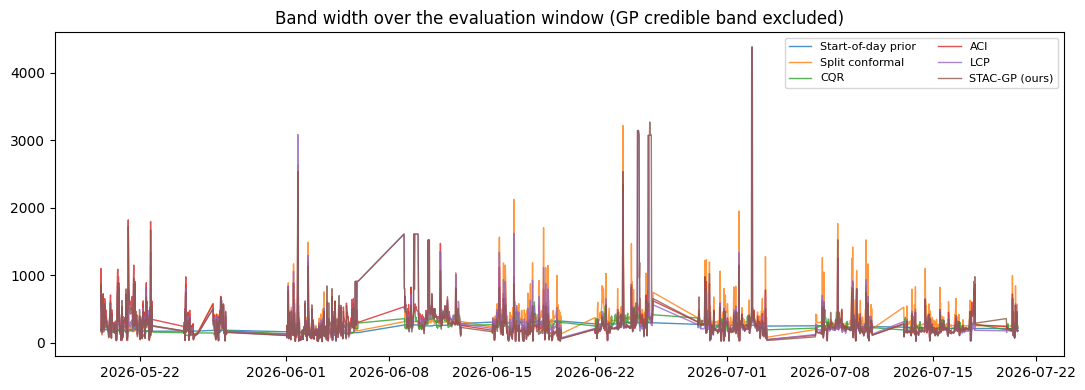

In [8]:
# same plot excluding the GP credible band (its scale dwarfs everything else)
fig, ax = plt.subplots(figsize=(11, 4))
for name, f in methods.items():
    if name == "GP credible band":
        continue
    fin = f[np.isfinite(f["width"])]
    ax.plot(fin["ts"], fin["width"], label=name, lw=1.0, alpha=0.8)
ax.set_title("Band width over the evaluation window (GP credible band excluded)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


## 6. Stress-response case study

Definition (stated explicitly, since there's no single textbook metric
here): a bar is a *shock* if its realised |return| exceeds 3x its own
trailing 40-bar median. For each shock we measure how many bars until the
method's own band half-width first reaches that shock's size again --
i.e. how fast the calibration "learns" that a move of that magnitude is
newly plausible.

In [9]:
Y = methods["STAC-GP (ours)"]["Y"].abs().to_numpy()
trailing_med = pd.Series(Y).rolling(40, min_periods=40).median().to_numpy()
is_shock = Y > 3.0 * trailing_med
is_shock[:40] = False
print(f"{is_shock.sum()} shock bars out of {len(Y)} evaluation bars ({is_shock.mean():.1%})")


186 shock bars out of 1686 evaluation bars (11.0%)


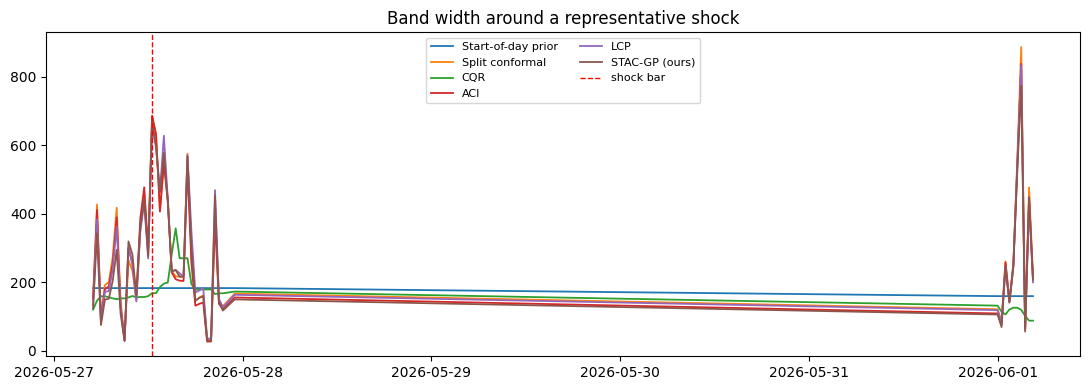

In [10]:
shock_idx = np.where(is_shock)[0][10]   # a representative example shock
f = methods["STAC-GP (ours)"]
lo, hi = max(0, shock_idx - 15), min(len(f), shock_idx + 30)
fig, ax = plt.subplots(figsize=(11, 4))
for name, fm in methods.items():
    if name == "GP credible band":
        continue
    ax.plot(fm["ts"].iloc[lo:hi], fm["width"].iloc[lo:hi], label=name, lw=1.3)
ax.axvline(f["ts"].iloc[shock_idx], color="red", ls="--", lw=1, label="shock bar")
ax.set_title("Band width around a representative shock")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


## 7. Notes and honest limitations

- **Third-party bid-offer**: not implemented, no data available -- reported
  as N/A
- **CQR** is scored against the raw Brownian prior `w_prior` (it replaces the
  GP entirely, so `w_GP` isn't a meaningful reference scale for it) --
  everything else in this table shares the frozen GP width.
- **Stress-response time** is a metric we defined for this comparison, not
  one lifted from a citation -- the 3x-trailing-median shock threshold and
  the "band first re-covers the shock size" response definition are
  reasonable but not the only reasonable choice.
- **Not yet done**: section 5.4's full ablation grid (bandwidth h, decay rho,
  window R sensitivity; scheduled-event case studies) and section 5.5
  (coupled vs. decoupled nonconformity scores) has not been implemented yet
- All hyperparameters (alpha, R, rho, h, gamma, feature set, train/cal/eval
  split) are not re-tuned for this comparison.
